In [1]:
# Cell 1 — setup
# (Run this first. Optional install for plot_model visualization)
!pip install -q pydot graphviz

import os
import numpy as np
import matplotlib.pyplot as pyplot
import tensorflow as tf
from tensorflow.keras.datasets.cifar10 import load_data
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Reshape, Flatten, Dropout,
                                     Conv2D, Conv2DTranspose, LeakyReLU, Input)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model
from tensorflow.keras.initializers import RandomNormal

# reproducibility
np.random.seed(42)
tf.random.set_seed(42)
print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
trainX shape: (50000, 32, 32, 3)


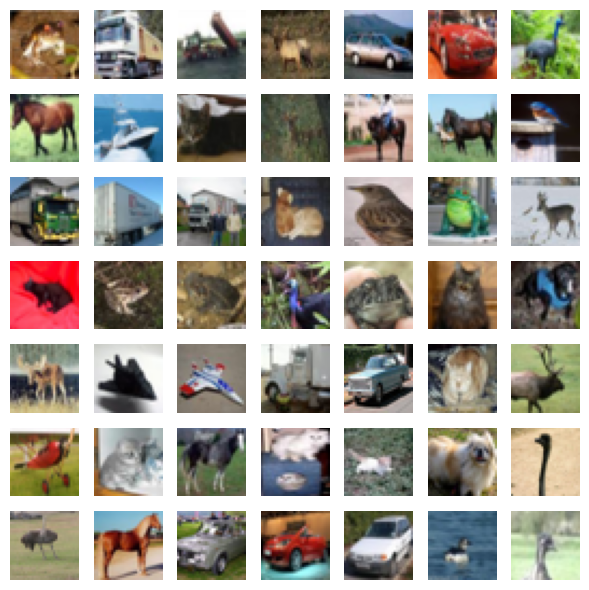

In [2]:
# Cell 2 — load and display some training images
(trainX, trainY), (testX, testY) = load_data()
print("trainX shape:", trainX.shape)

# Show first 49 images
n_samples = 49
pyplot.figure(figsize=(6,6))
for i in range(n_samples):
    pyplot.subplot(7,7,i+1)
    pyplot.axis("off")
    # CIFAR images are uint8 [0..255]
    pyplot.imshow(trainX[i])
pyplot.tight_layout()
pyplot.show()


In [3]:
# Cell 3 — discriminator definition
def define_discriminator(in_shape=(32,32,3)):
    init = RandomNormal(stddev=0.02)
    model = Sequential()
    model.add(Conv2D(64, (3,3), padding='same', input_shape=in_shape, kernel_initializer=init))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Conv2D(128,(3,3), strides=(2,2), padding='same', kernel_initializer=init))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Conv2D(128,(3,3), strides=(2,2), padding='same', kernel_initializer=init))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Conv2D(256,(3,3), strides=(2,2), padding='same', kernel_initializer=init))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Flatten())
    model.add(Dropout(0.4))
    model.add(Dense(1, activation='sigmoid'))
    # compile
    opt = Adam(learning_rate=0.0002, beta_1=0.5)
    model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])
    return model

# create and summarize
d_model = define_discriminator()
d_model.summary()

# optional: save a plot (works if pydot/graphviz installed)
try:
    plot_model(d_model, to_file='discriminator_plot.png', show_shapes=True, show_layer_names=True)
    print("Saved discriminator_plot.png")
except Exception as e:
    print("plot_model skipped (pydot/graphviz may be missing).", e)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 522,497 (1.99 MB)

 Trainable params: 522,497 (1.99 MB)

 Non-trainable params: 0 (0.00 B)

Saved discriminator_plot.png


In [4]:
# Cell 4 — data helpers

# load real samples scaled to [-1,1]
def load_real_samples():
    (trainX, _), (_, _) = load_data()
    X = trainX.astype('float32')
    X = (X - 127.5) / 127.5
    return X

# select random real samples
def generate_real_samples(dataset, n_samples):
    ix = np.random.randint(0, dataset.shape[0], n_samples)
    X = dataset[ix]
    y = np.ones((n_samples, 1))
    return X, y

# generate fake samples as pure random noise (for initial discriminator test)
def generate_fake_samples_random(n_samples):
    # uniform random values in [-1,1]
    X = -1 + np.random.rand(n_samples, 32, 32, 3) * 2.0
    y = np.zeros((n_samples, 1))
    return X, y

# train discriminator for a few iterations (using random fakes)
def train_discriminator_simple(model, dataset, n_iter=10, n_batch=128):
    half = n_batch // 2
    for i in range(n_iter):
        X_real, y_real = generate_real_samples(dataset, half)
        _, acc_real = model.train_on_batch(X_real, y_real)
        X_fake, y_fake = generate_fake_samples_random(half)
        _, acc_fake = model.train_on_batch(X_fake, y_fake)
        print(f">Epoch {i+1}: real={acc_real*100:.0f}% fake={acc_fake*100:.0f}%")


In [5]:
# Cell 5 — generator definition
def define_generator(latent_dim):
    init = RandomNormal(stddev=0.02)
    model = Sequential()
    n_nodes = 256 * 4 * 4
    model.add(Dense(n_nodes, input_dim=latent_dim, kernel_initializer=init))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Reshape((4,4,256)))
    # upsample to 8x8
    model.add(Conv2DTranspose(128,(4,4), strides=(2,2), padding='same', kernel_initializer=init))
    model.add(LeakyReLU(alpha=0.2))
    # upsample to 16x16
    model.add(Conv2DTranspose(128,(4,4), strides=(2,2), padding='same', kernel_initializer=init))
    model.add(LeakyReLU(alpha=0.2))
    # upsample to 32x32
    model.add(Conv2DTranspose(128,(4,4), strides=(2,2), padding='same', kernel_initializer=init))
    model.add(LeakyReLU(alpha=0.2))
    # output layer: tanh to produce values in [-1,1]
    model.add(Conv2D(3, (3,3), activation='tanh', padding='same', kernel_initializer=init))
    return model

# test summary
latent_dim = 100
g_model = define_generator(latent_dim)
g_model.summary()

try:
    plot_model(g_model, to_file='generator_plot.png', show_shapes=True, show_layer_names=True)
    print("Saved generator_plot.png")
except Exception as e:
    print("plot_model skipped (pydot/graphviz may be missing).", e)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 4096)           │       413,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 128)      │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 3)      │         3,459 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,466,115 (5.59 MB)

 Trainable params: 1,466,115 (5.59 MB)

 Non-trainable params: 0 (0.00 B)

Saved generator_plot.png


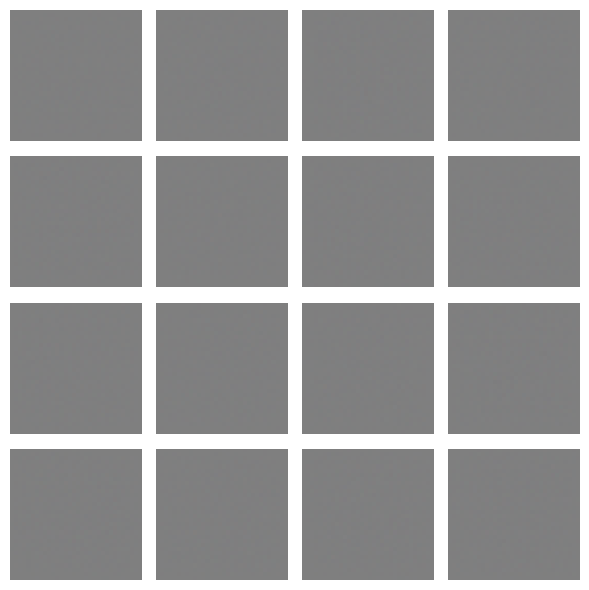

In [6]:
# Cell 6 — generate sample images using generator
def generate_latent_points(latent_dim, n_samples):
    x_input = np.random.randn(latent_dim * n_samples)  # normal distribution often works better
    x_input = x_input.reshape(n_samples, latent_dim)
    return x_input

def generate_fake_samples_from_generator(g_model, latent_dim, n_samples):
    x_input = generate_latent_points(latent_dim, n_samples)
    X = g_model.predict(x_input, verbose=0)
    y = np.zeros((n_samples, 1))
    return X, y

# generate examples
n = 16
X, _ = generate_fake_samples_from_generator(g_model, latent_dim, n)
# scale to [0,1] for plotting
X = (X + 1) / 2.0
pyplot.figure(figsize=(6,6))
for i in range(n):
    pyplot.subplot(4,4,i+1)
    pyplot.axis('off')
    pyplot.imshow(np.clip(X[i], 0, 1))
pyplot.tight_layout()
pyplot.show()


In [14]:
# Cell 7 — define GAN, plots, and training loop

def define_gan(g_model, d_model, latent_dim):
    # make discriminator not trainable when training GAN
    d_model.trainable = False
    gan_input = Input(shape=(latent_dim,))
    gen_output = g_model(gan_input)
    gan_output = d_model(gen_output)
    model = Model(gan_input, gan_output)
    opt = Adam(learning_rate=0.0002, beta_1=0.5)
    model.compile(loss='binary_crossentropy', optimizer=opt)
    return model

# save plot of generated images
def save_plot(examples, epoch, n=5, out_dir='plots'):
    os.makedirs(out_dir, exist_ok=True)
    examples = (examples + 1) / 2.0
    pyplot.figure(figsize=(6,6))
    for i in range(n*n):
        pyplot.subplot(n,n,1+i)
        pyplot.axis('off')
        pyplot.imshow(np.clip(examples[i], 0, 1))
    filename = os.path.join(out_dir, f'generated_plot_e{epoch+1:03d}.png')
    pyplot.tight_layout()
    pyplot.savefig(filename)
    pyplot.close()
    print("Saved", filename)

# evaluate and save generator and report
def summarize_performance(epoch, g_model, d_model, dataset, latent_dim, n_samples=100):
    X_real, y_real = generate_real_samples(dataset, n_samples)
    _, acc_real = d_model.evaluate(X_real, y_real, verbose=0)
    X_fake, _ = generate_fake_samples_from_generator(g_model, latent_dim, n_samples)
    y_fake = np.zeros((n_samples,1))
    _, acc_fake = d_model.evaluate(X_fake, y_fake, verbose=0)
    print(f">Epoch {epoch+1}: Accuracy real={acc_real*100:.0f}% fake={acc_fake*100:.0f}%")
    # save sample plot and generator
    save_plot(X_fake, epoch, n=5)
    filename = f'generator_model_{epoch+1:03d}.h5'
    g_model.save(filename)
    print("Saved generator model to", filename)

# full training loop
def train(g_model, d_model, gan_model, dataset, latent_dim, n_epochs=10, n_batch=64):
    bat_per_epo = int(dataset.shape[0] / n_batch)
    half_batch = int(n_batch / 2)
    for epoch in range(n_epochs):
        for batch in range(bat_per_epo):
            # real samples
            X_real, y_real = generate_real_samples(dataset, half_batch)
            # fake examples from generator
            X_fake, y_fake = generate_fake_samples_from_generator(g_model, latent_dim, half_batch)
            # update discriminator on real+fake
            X, y = np.vstack((X_real, X_fake)), np.vstack((y_real, y_fake))
            d_loss, d_acc = d_model.train_on_batch(X, y)
            # prepare points in latent space for generator update
            X_gan = generate_latent_points(latent_dim, n_batch)
            y_gan = np.ones((n_batch, 1))  # want generator to fool discriminator
            g_loss = gan_model.train_on_batch(X_gan, y_gan)
            if (batch+1) % 50 == 0 or batch == 0:
                print(f">Epoch {epoch+1}, Batch {batch+1}/{bat_per_epo}, d_loss={d_loss:.3f}, d_acc={d_acc:.3f}, g_loss={g_loss:.3f}")
        # optionally summarize and save every few epochs
        if (epoch+1) % 5 == 0 or (epoch+1) == n_epochs:
            summarize_performance(epoch, g_model, d_model, dataset, latent_dim, n_samples=100)


In [ ]:
# Cell 8 — prepare and run training (small for demo)
latent_dim = 100
d_model = define_discriminator()
g_model = define_generator(latent_dim)
gan_model = define_gan(g_model, d_model, latent_dim)

dataset = load_real_samples()
print("Dataset loaded, shape:", dataset.shape)

# quick test of discriminator training using random fakes (optional)
print("Quick discriminator sanity training with random fakes:")
train_discriminator_simple(d_model, dataset, n_iter=3, n_batch=64)

# Now train full GAN for a short demo (small epochs/batch to keep runtime small)
# Increase n_epochs and n_batch for serious training.
train(g_model, d_model, gan_model, dataset, latent_dim, n_epochs=50, n_batch=128)


Dataset loaded, shape: (50000, 32, 32, 3)
Quick discriminator sanity training with random fakes:
>Epoch 1: real=47% fake=44%
>Epoch 2: real=54% fake=52%
>Epoch 3: real=54% fake=47%
>Epoch 1, Batch 1/390, d_loss=0.693, d_acc=0.500, g_loss=0.693
>Epoch 1, Batch 50/390, d_loss=0.701, d_acc=0.335, g_loss=0.677
>Epoch 1, Batch 100/390, d_loss=0.708, d_acc=0.328, g_loss=0.663
>Epoch 1, Batch 150/390, d_loss=0.712, d_acc=0.327, g_loss=0.656
>Epoch 1, Batch 200/390, d_loss=0.715, d_acc=0.325, g_loss=0.651
>Epoch 1, Batch 250/390, d_loss=0.717, d_acc=0.325, g_loss=0.648
>Epoch 1, Batch 300/390, d_loss=0.718, d_acc=0.326, g_loss=0.645
>Epoch 1, Batch 350/390, d_loss=0.719, d_acc=0.325, g_loss=0.643
>Epoch 2, Batch 1/390, d_loss=0.720, d_acc=0.325, g_loss=0.641
>Epoch 2, Batch 50/390, d_loss=0.721, d_acc=0.325, g_loss=0.640
>Epoch 2, Batch 100/390, d_loss=0.722, d_acc=0.325, g_loss=0.638
>Epoch 2, Batch 150/390, d_loss=0.722, d_acc=0.325, g_loss=0.637
>Epoch 2, Batch 200/390, d_loss=0.723, d_acc=

Saved plots/generated_plot_e005.png
Saved generator model to generator_model_005.h5
>Epoch 6, Batch 1/390, d_loss=0.746, d_acc=0.175, g_loss=0.628
>Epoch 6, Batch 50/390, d_loss=0.730, d_acc=0.316, g_loss=0.628
>Epoch 6, Batch 100/390, d_loss=0.730, d_acc=0.324, g_loss=0.628
>Epoch 6, Batch 150/390, d_loss=0.730, d_acc=0.321, g_loss=0.628
>Epoch 6, Batch 200/390, d_loss=0.730, d_acc=0.319, g_loss=0.628
>Epoch 6, Batch 250/390, d_loss=0.730, d_acc=0.321, g_loss=0.628
>Epoch 6, Batch 300/390, d_loss=0.730, d_acc=0.321, g_loss=0.628
>Epoch 6, Batch 350/390, d_loss=0.730, d_acc=0.321, g_loss=0.628
>Epoch 7, Batch 1/390, d_loss=0.730, d_acc=0.321, g_loss=0.628
>Epoch 7, Batch 50/390, d_loss=0.730, d_acc=0.322, g_loss=0.628
>Epoch 7, Batch 100/390, d_loss=0.730, d_acc=0.322, g_loss=0.628
>Epoch 7, Batch 150/390, d_loss=0.730, d_acc=0.322, g_loss=0.627
>Epoch 7, Batch 200/390, d_loss=0.730, d_acc=0.322, g_loss=0.627
>Epoch 7, Batch 250/390, d_loss=0.730, d_acc=0.322, g_loss=0.627
>Epoch 7, Ba

Saved plots/generated_plot_e010.png
Saved generator model to generator_model_010.h5
>Epoch 11, Batch 1/390, d_loss=0.750, d_acc=0.202, g_loss=0.626
>Epoch 11, Batch 50/390, d_loss=0.733, d_acc=0.318, g_loss=0.626
>Epoch 11, Batch 100/390, d_loss=0.733, d_acc=0.322, g_loss=0.626
>Epoch 11, Batch 150/390, d_loss=0.733, d_acc=0.323, g_loss=0.625
>Epoch 11, Batch 200/390, d_loss=0.733, d_acc=0.323, g_loss=0.625
>Epoch 11, Batch 250/390, d_loss=0.734, d_acc=0.323, g_loss=0.625
>Epoch 11, Batch 300/390, d_loss=0.734, d_acc=0.323, g_loss=0.625
>Epoch 11, Batch 350/390, d_loss=0.734, d_acc=0.324, g_loss=0.625
>Epoch 12, Batch 1/390, d_loss=0.734, d_acc=0.324, g_loss=0.625
>Epoch 12, Batch 50/390, d_loss=0.734, d_acc=0.323, g_loss=0.625
>Epoch 12, Batch 100/390, d_loss=0.734, d_acc=0.324, g_loss=0.625
>Epoch 12, Batch 150/390, d_loss=0.734, d_acc=0.324, g_loss=0.625
>Epoch 12, Batch 200/390, d_loss=0.734, d_acc=0.324, g_loss=0.624
>Epoch 12, Batch 250/390, d_loss=0.735, d_acc=0.324, g_loss=0.62

Saved plots/generated_plot_e015.png
Saved generator model to generator_model_015.h5
>Epoch 16, Batch 1/390, d_loss=0.764, d_acc=0.197, g_loss=0.621
>Epoch 16, Batch 50/390, d_loss=0.743, d_acc=0.326, g_loss=0.620
>Epoch 16, Batch 100/390, d_loss=0.742, d_acc=0.322, g_loss=0.620
>Epoch 16, Batch 150/390, d_loss=0.742, d_acc=0.323, g_loss=0.620
>Epoch 16, Batch 200/390, d_loss=0.743, d_acc=0.322, g_loss=0.620
>Epoch 16, Batch 250/390, d_loss=0.743, d_acc=0.322, g_loss=0.620
>Epoch 16, Batch 300/390, d_loss=0.743, d_acc=0.322, g_loss=0.620
>Epoch 16, Batch 350/390, d_loss=0.743, d_acc=0.322, g_loss=0.620
>Epoch 17, Batch 1/390, d_loss=0.743, d_acc=0.322, g_loss=0.619
>Epoch 17, Batch 50/390, d_loss=0.743, d_acc=0.322, g_loss=0.619
>Epoch 17, Batch 100/390, d_loss=0.743, d_acc=0.322, g_loss=0.619
>Epoch 17, Batch 150/390, d_loss=0.743, d_acc=0.322, g_loss=0.619
>Epoch 17, Batch 200/390, d_loss=0.743, d_acc=0.322, g_loss=0.619
>Epoch 17, Batch 250/390, d_loss=0.743, d_acc=0.322, g_loss=0.61

Saved plots/generated_plot_e020.png
Saved generator model to generator_model_020.h5
>Epoch 21, Batch 1/390, d_loss=0.774, d_acc=0.154, g_loss=0.615
>Epoch 21, Batch 50/390, d_loss=0.750, d_acc=0.318, g_loss=0.615
>Epoch 21, Batch 100/390, d_loss=0.749, d_acc=0.322, g_loss=0.614
>Epoch 21, Batch 150/390, d_loss=0.749, d_acc=0.325, g_loss=0.614
>Epoch 21, Batch 200/390, d_loss=0.749, d_acc=0.325, g_loss=0.614
>Epoch 21, Batch 250/390, d_loss=0.749, d_acc=0.323, g_loss=0.614
>Epoch 21, Batch 300/390, d_loss=0.750, d_acc=0.323, g_loss=0.614
>Epoch 21, Batch 350/390, d_loss=0.750, d_acc=0.324, g_loss=0.614
>Epoch 22, Batch 1/390, d_loss=0.750, d_acc=0.325, g_loss=0.614
>Epoch 22, Batch 50/390, d_loss=0.750, d_acc=0.324, g_loss=0.613
>Epoch 22, Batch 100/390, d_loss=0.750, d_acc=0.324, g_loss=0.613
>Epoch 22, Batch 150/390, d_loss=0.750, d_acc=0.325, g_loss=0.613
>Epoch 22, Batch 200/390, d_loss=0.750, d_acc=0.324, g_loss=0.613
>Epoch 22, Batch 250/390, d_loss=0.750, d_acc=0.325, g_loss=0.61

Saved plots/generated_plot_e025.png
Saved generator model to generator_model_025.h5
>Epoch 26, Batch 1/390, d_loss=0.782, d_acc=0.158, g_loss=0.609
>Epoch 26, Batch 50/390, d_loss=0.755, d_acc=0.314, g_loss=0.609
>Epoch 26, Batch 100/390, d_loss=0.755, d_acc=0.318, g_loss=0.609
>Epoch 26, Batch 150/390, d_loss=0.755, d_acc=0.318, g_loss=0.609
>Epoch 26, Batch 200/390, d_loss=0.755, d_acc=0.318, g_loss=0.609
>Epoch 26, Batch 250/390, d_loss=0.755, d_acc=0.321, g_loss=0.609
>Epoch 26, Batch 300/390, d_loss=0.755, d_acc=0.321, g_loss=0.609
>Epoch 26, Batch 350/390, d_loss=0.755, d_acc=0.322, g_loss=0.608
>Epoch 27, Batch 1/390, d_loss=0.755, d_acc=0.321, g_loss=0.608
>Epoch 27, Batch 50/390, d_loss=0.755, d_acc=0.322, g_loss=0.608
>Epoch 27, Batch 100/390, d_loss=0.755, d_acc=0.322, g_loss=0.608
>Epoch 27, Batch 150/390, d_loss=0.755, d_acc=0.322, g_loss=0.608
>Epoch 27, Batch 200/390, d_loss=0.755, d_acc=0.321, g_loss=0.608
>Epoch 27, Batch 250/390, d_loss=0.755, d_acc=0.321, g_loss=0.60

Saved plots/generated_plot_e030.png
Saved generator model to generator_model_030.h5
>Epoch 31, Batch 1/390, d_loss=0.786, d_acc=0.193, g_loss=0.605
>Epoch 31, Batch 50/390, d_loss=0.759, d_acc=0.314, g_loss=0.604
>Epoch 31, Batch 100/390, d_loss=0.758, d_acc=0.320, g_loss=0.604
>Epoch 31, Batch 150/390, d_loss=0.758, d_acc=0.321, g_loss=0.604
>Epoch 31, Batch 200/390, d_loss=0.758, d_acc=0.322, g_loss=0.604
>Epoch 31, Batch 250/390, d_loss=0.758, d_acc=0.322, g_loss=0.604
>Epoch 31, Batch 300/390, d_loss=0.758, d_acc=0.322, g_loss=0.604
>Epoch 31, Batch 350/390, d_loss=0.758, d_acc=0.323, g_loss=0.604
>Epoch 32, Batch 1/390, d_loss=0.758, d_acc=0.323, g_loss=0.604
>Epoch 32, Batch 50/390, d_loss=0.758, d_acc=0.323, g_loss=0.604
>Epoch 32, Batch 100/390, d_loss=0.758, d_acc=0.323, g_loss=0.603
>Epoch 32, Batch 150/390, d_loss=0.758, d_acc=0.323, g_loss=0.603
>Epoch 32, Batch 200/390, d_loss=0.758, d_acc=0.323, g_loss=0.603
>Epoch 32, Batch 250/390, d_loss=0.758, d_acc=0.323, g_loss=0.60

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step


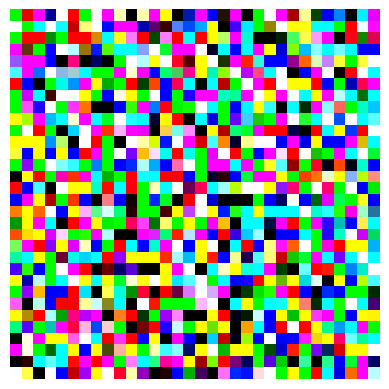

100

In [13]:
from tensorflow.keras.models import load_model
from numpy.random import randn
from matplotlib import pyplot

def generate_latent_points(latent_dim, n_samples):
    x_input = randn(latent_dim * n_samples)
    x_input = x_input.reshape(n_samples, latent_dim)
    return x_input

def create_plot(examples,n):
  for i in range(n*n):
    pyplot.subplot(n,n,i+1)
    pyplot.axis('off')
    pyplot.imshow(examples[i,:,:])
  pyplot.show()

model = load_model('generator_model_095.h5')
latent_points = generate_latent_points(100,100)
x = model.predict(latent_points)
x = (x+1)/2.0
create_plot(x,1)
x.shape[0]